# Imports

In [309]:
# Imports
import numpy as np
from numpy import nan
import pandas as pd
import matplotlib.pyplot as plt
import os
import scipy
import scipy.stats as stats
from scipy.spatial.distance import cdist
import itertools
from tqdm.auto import tqdm
import seaborn as sns
import importlib
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import bernoulli
import warnings
from GP import *
from plotter import *
from scipy.special import softmax
from scipy.spatial.distance import cdist

# 2AFC

## Simulations

  0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

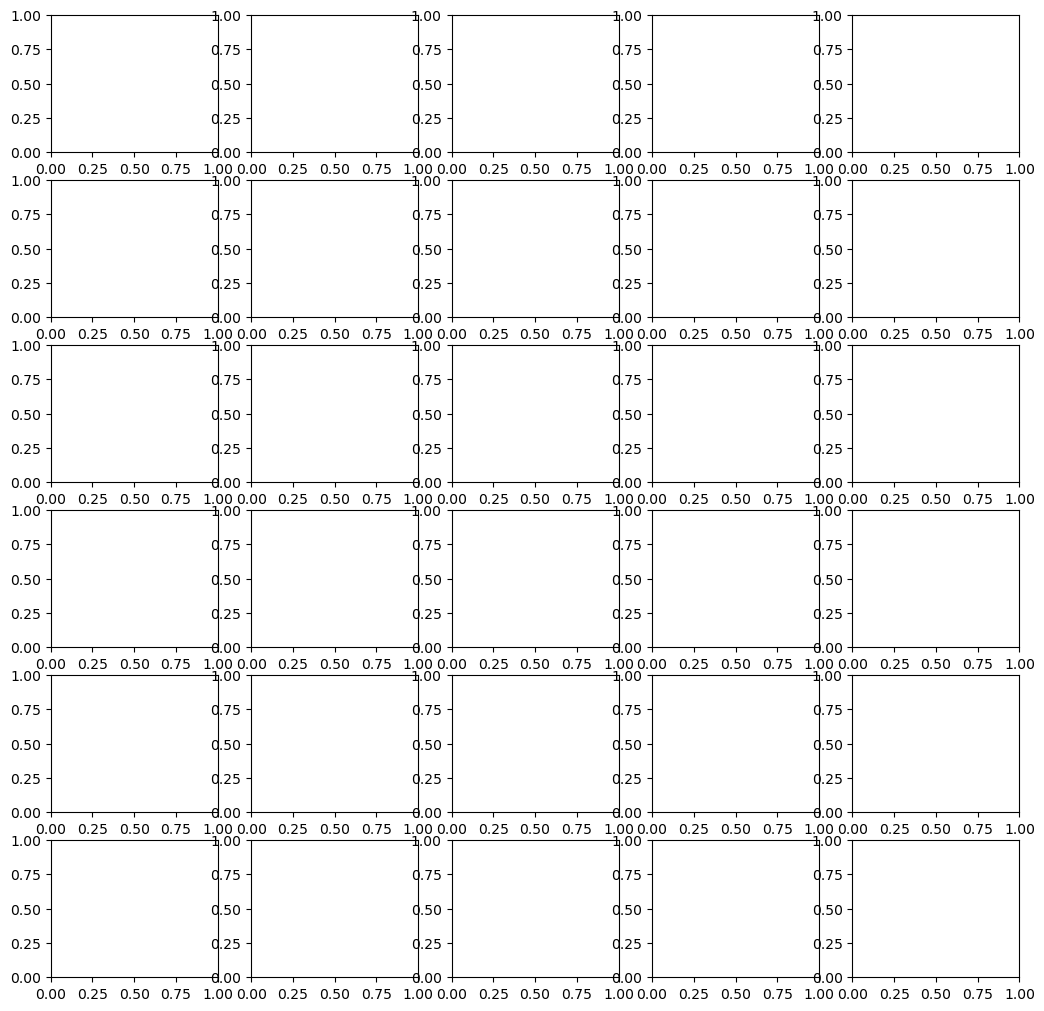

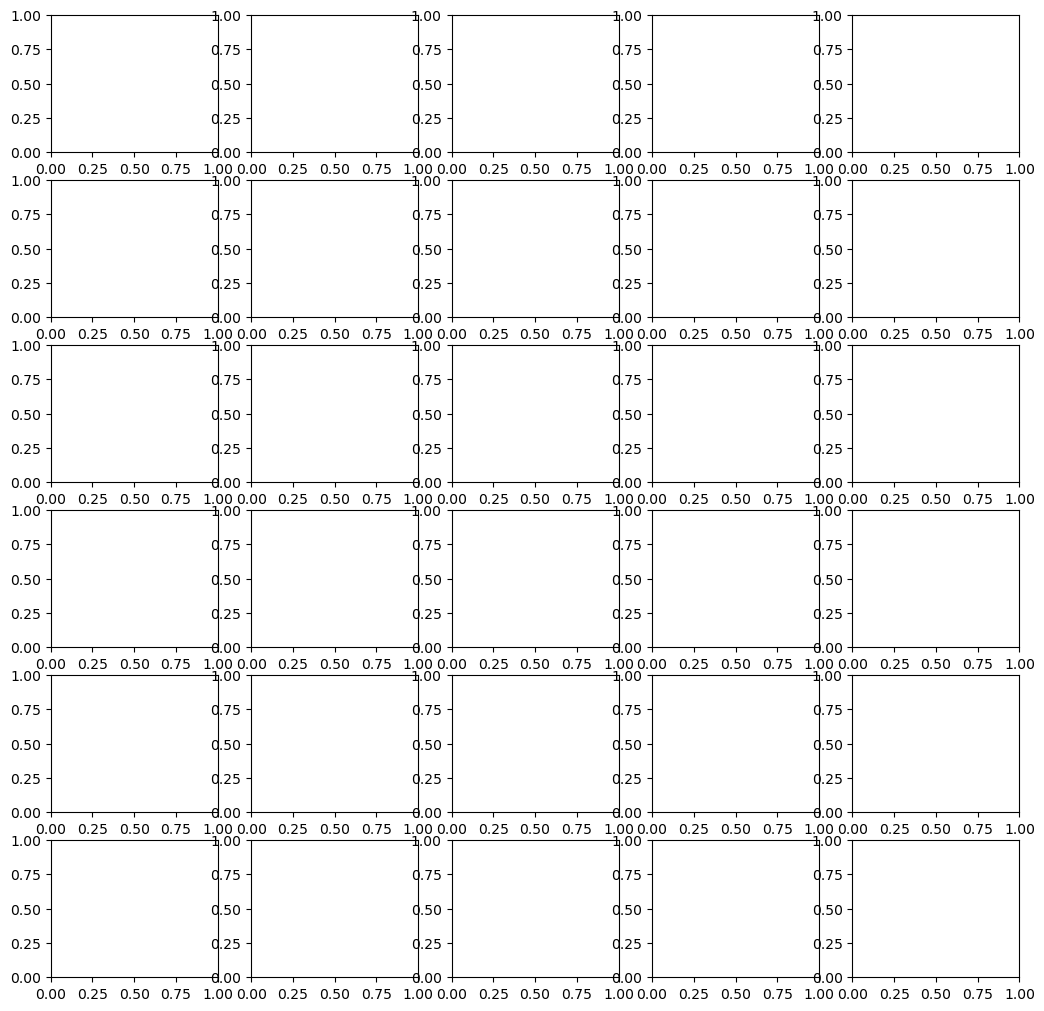

In [269]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

### zero in on interesting combos

## inititialise the GP
N = 10
c = [1]
scale = [1]
theta = [0]
sigma_f = [1]
length_scale = [N/2.5]
# length_scale = np.linspace(1,10,5, dtype = int)
period = [4]
# period = np.linspace(1,10,10)
periodic_length_scale = [4]
# periodic_length_scale = [N/2.5]
# periodic_length_scale = np.linspace(1,10,10)
# periodic_theta = [0]
periodic_theta = [np.pi/4]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## init dict to store data
gp_dict = {
    'gen_kernel': [],
    'inf_kernel': [],
    'n_obs': [],
    'trial': [],
    'k_mll': [],
    'x_1': [],
    'x_2': [],
    'reward_1': [],
    'reward_2': [],
    'CP_1': [],
    'CP_2': [],
    'p(correct)': []
}
for param in param_names:
    gp_dict[param] = []

## loop through parameter initialisations
for pci in tqdm(range(len(param_combos))):
    params = param_combos[pci]

    ## define koi
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        gp.K_lin_x,
        gp.K_lin_y,
        # gp.K_rbf,
        # gp.K_rbf_x,
        # gp.K_rbf_y,
        gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        gp.K_lin_x*gp.K_periodic_x,
        gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        'Linear_x',
        'Linear_y',
        # 'RBF',
        # 'RBF_x',
        # 'RBF_y',
        # 'Periodic_x',
        # 'Periodic_y',
        'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        'Linear_x*Periodic_x',
        'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]


    ## init plots 
    n_k = len(koi)
    n_trials = 500
    if (pci == len(param_combos)-1):
        fig, axs = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))
        fig2, axs2 = plt.subplots(n_k+1,n_k, figsize=(n_k*2.5,n_k*2.5))



    ## loop through combos
    for kg, k_gen in enumerate(koi):
        k_gen_name = kernel_names[kg]
        gp.k_check(k_gen)

        ## loop through trials
        for t in range(n_trials):
        
            ## sample from combo kernel
            samples = gp.sample(k_gen)

            ## generate observations
            n_obs = 10
            all_obs = gp.gen_obs(samples, n_obs)
            
            ## for each trial, select two random points to choose between
            preds = gp.gen_preds(samples).squeeze()


            ## plot
            if (t == n_trials-1) & (pci == len(param_combos)-1):
                plot_r(samples, axs[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_r(samples, axs2[0,kg], k_gen_name, cbar = kg==(len(koi)-1))
                plot_obs(all_obs, axs[0,kg], text=False)
                plot_obs(all_obs, axs2[0,kg], text=False)
            
            ## loop through inference kernels
            for ki, k_inf in enumerate(koi):
                k_inf_name = kernel_names[ki]

                ## incrementally increase the number of observations
                for o in range(n_obs):
                    obs = all_obs[:o+1]

                    ## calculate posterior of the points to compare, given the observations made so far
                    post_mean, post_cov = gp.post_pred(k_inf, obs, preds[:,0].astype(int))
                    # temp = 0.1
                    # choice_prob = softmax(post_mean/temp)
                    # choice_prob = gp.sigmoid(diff, tau)
                    choice_prob = [scipy.stats.norm.cdf(post_mean[0]-post_mean[1], 0, np.sum(np.diag(post_cov)))]
                    choice_prob.append(1-choice_prob[0])


                    ## compute log marginal likelihood under this kernel
                    ll = gp.likelihood(k_inf, obs)

                    ## save data
                    gp_dict['gen_kernel'].append(k_gen_name)
                    gp_dict['inf_kernel'].append(k_inf_name)
                    gp_dict['trial'].append(t)
                    gp_dict['k_mll'].append(ll)
                    gp_dict['n_obs'].append(o+1)
                    ## should also save the info about the observations somewhere
                    gp_dict['x_1'].append(preds[0,0])
                    gp_dict['x_2'].append(preds[1,0])
                    gp_dict['reward_1'].append(preds[0,-1])
                    gp_dict['reward_2'].append(preds[1,-1])
                    gp_dict['CP_1'].append(choice_prob[0])
                    gp_dict['CP_2'].append(choice_prob[1])
                    gp_dict['p(correct)'].append(choice_prob[np.argmax(preds[:,-1])])

                    ## save params
                    for param in param_names:
                        gp_dict[param].append(params[param_names.index(param)])
                
                ## plot the full posterior distribution once all observations have been made
                full_post_mean, _ = gp.post_pred(k_inf, obs)
                if (t == n_trials-1) & (pci == len(param_combos)-1):
                    plot_r(full_post_mean.reshape(N,N), axs[ki+1,kg], cbar = kg==(len(koi)-1))
                    RPE = samples-full_post_mean.reshape(N,N)
                    plot_RPE(RPE, axs2[ki+1,kg], cbar = (kg==(len(koi)-1)))
            

        ## loop through rows and add y-axis to the leftmost column
        if (t == n_trials-1) & (pci == len(param_combos)-1):
            for i in range(n_k):
                axs[i+1,0].set_ylabel(kernel_names[i])
                axs2[i+1,0].set_ylabel(kernel_names[i])

## convert ll_dict to df
df_gp = pd.DataFrame(gp_dict)

## Plots

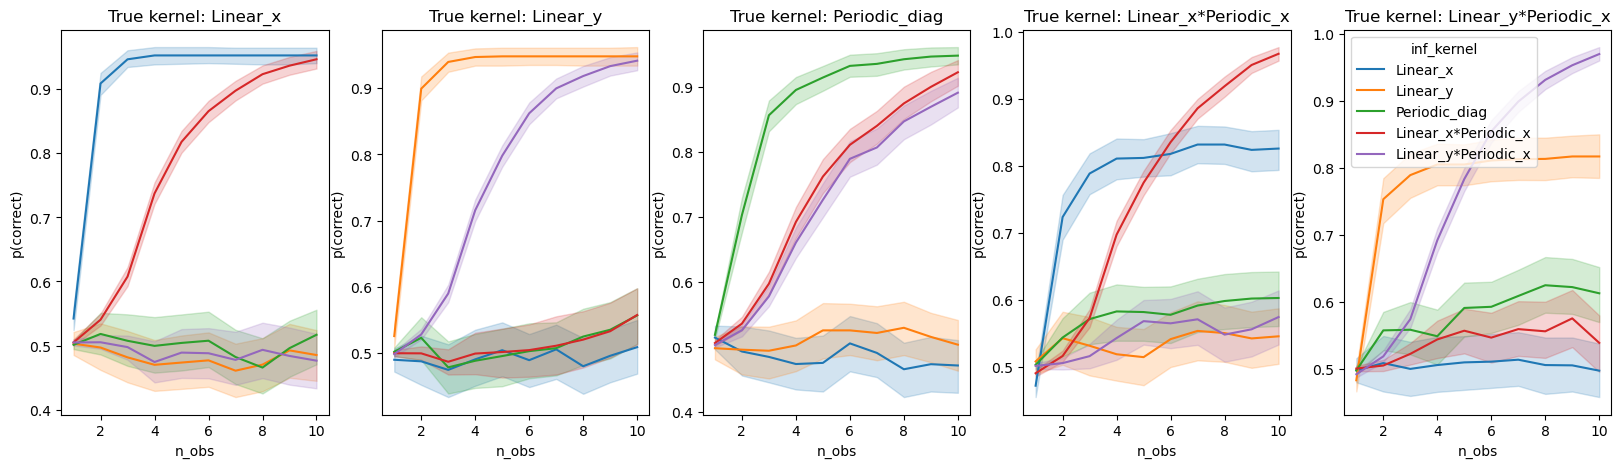

In [6]:
## accuracy

# param_of_interest = scale.copy()
# param_of_interest = length_scale.copy()
# param_of_interest = period.copy()
param_of_interest = periodic_length_scale.copy()
for p in periodic_length_scale:
    data_tmp = df_gp.loc[df_gp['periodic_length_scale']==p]
    fig, axs = plt.subplots(1, n_k, figsize=(4*n_k, 5))
    for gki, gen_k in enumerate(data_tmp['gen_kernel'].unique()):
        sns.lineplot(data = data_tmp.loc[data_tmp['gen_kernel']==gen_k], x = 'n_obs', y = 'p(correct)', hue = 'inf_kernel', ax = axs[gki], legend = gki==n_k-1)
        axs[gki].set_title('True kernel: '+gen_k)
    # plt.suptitle((p))


## MLL

fig, axs = plt.subplots(1,n_k, figsize=(20,5))
for i in range(n_k):
    sns.lineplot(data = df_gp.loc[df_gp['gen_kernel'] == kernel_names[i]], x = 'n_obs', y = 'k_mll', hue = 'inf_kernel', ax = axs[i], legend=i==0, )
    axs[i].set_title('True kernel: '+kernel_names[i])
    axs[i].set_xlabel('N obs')
    axs[i].set_ylabel('')
    # axs[i].set_ylim(-100,25)
axs[0].set_ylabel('log marginal likelihood')
# axs[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

## Trajectories

In [516]:
np.random.randint(1,N,(2,2))

array([[12,  0],
       [10, 12]])

In [543]:
cdist(pair, pair)

array([[0.        , 2.23606798],
       [2.23606798, 0.        ]])

In [765]:
del gp_dict

  0%|          | 0/100 [00:00<?, ?it/s]

,trial,n_simple,n_simple_x,n_simple_y,n_optimal,simple_cost,simple_cost_x,simple_cost_y,optimal_cost,optimality,optimality_x,optimality_y
count,100.000000,100.000000,0.0,0.0,100.000000,100.000000,0.0,0.0,100.000000,100.000000,0.0,0.0
mean,9.500000,14.800000,NaN,NaN,16.130000,7.284345,NaN,NaN,5.941459,0.796636,NaN,NaN
std,5.795331,1.477098,NaN,NaN,3.037327,2.718178,NaN,NaN,2.549151,0.194082,NaN,NaN
min,0.000000,12.000000,NaN,NaN,12.000000,0.337376,NaN,NaN,0.049065,0.145430,NaN,NaN
25%,4.750000,13.750000,NaN,NaN,14.000000,6.084787,NaN,NaN,4.160460,0.700500,NaN,NaN
50%,9.500000,15.000000,NaN,NaN,15.000000,7.474006,NaN,NaN,6.469026,0.856442,NaN,NaN
75%,14.250000,16.000000,NaN,NaN,17.000000,8.792802,NaN,NaN,7.623270,0.951817,NaN,NaN
max,19.000000,18.000000,NaN,NaN,26.000000,13.283155,NaN,NaN,12.868762,1.000000,NaN,NaN


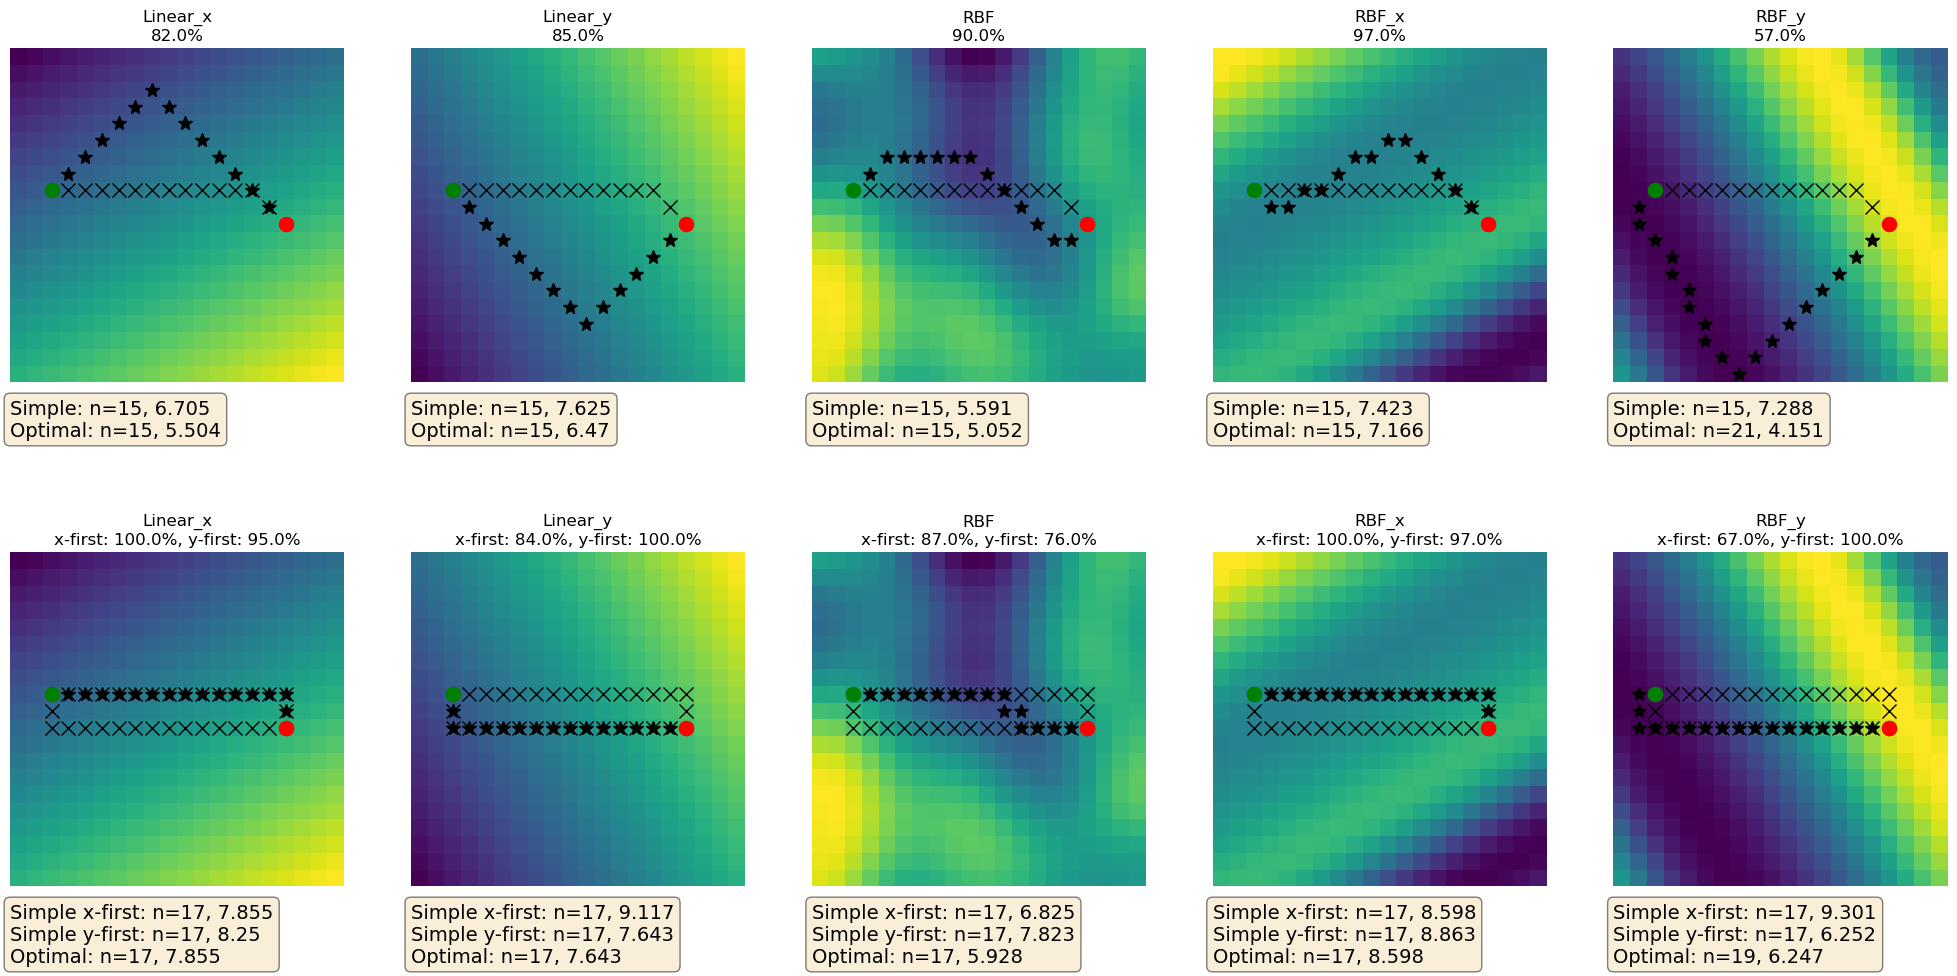

In [786]:
import GP
importlib.reload(GP)
from GP import *

import plotter
importlib.reload(plotter)
from plotter import *

# ## inititialise the GP
N = 20
c = [1]
scale = [1]
# theta = [0]
theta = [np.pi/3]
sigma_f = [1]
length_scale = [N/5]
# length_scale = np.linspace(1,5,5, dtype = int)
period = [4]
# period = np.linspace(1,10,10)
periodic_length_scale = [4]
# periodic_length_scale = [N/2.5]
# periodic_length_scale = np.linspace(1,10,10)
# periodic_theta = [0]
periodic_theta = [np.pi/4]
# GP_params = [c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta]
param_combos = list(itertools.product(c, scale, theta, sigma_f, length_scale, period, periodic_length_scale, periodic_theta))
param_names = ['c', 'scale', 'theta', 'sigma_f', 'length_scale', 'period', 'periodic_length_scale', 'periodic_theta']

## loop through parameter initialisations
for pci in range(len(param_combos)):
    params = param_combos[pci]

    ## GP init
    metric = 'chebyshev'
    metric = 'manhattan'
    metrics = ['chebyshev', 'manhattan']
    gp = GP_world(N, params)
    koi = [
        
        ## base kernels
        # gp.K_lin,
        gp.K_lin_x,
        gp.K_lin_y,
        gp.K_rbf,
        gp.K_rbf_x,
        gp.K_rbf_y,
        # gp.K_periodic_x,
        # gp.K_periodic_y,


        ## combos
        # gp.K_lin*gp.K_periodic_x,
        # gp.K_lin*gp.K_periodic_y,
        # gp.K_lin_x*gp.K_periodic_x,
        # gp.K_lin_y*gp.K_periodic_x,
        # gp.K_rbf_x*gp.K_periodic_x,
        # gp.K_rbf_y*gp.K_periodic_x,
        # gp.K_periodic_x*gp.K_periodic_y
    ]

    kernel_names = [
        ## base kernels
        # 'Linear',
        'Linear_x',
        'Linear_y',
        'RBF',
        'RBF_x',
        'RBF_y',
        # 'Periodic_x',
        # 'Periodic_y',
        'Periodic_diag',

        ## combos
        # 'Linear*Periodic_x',
        # 'Linear*Periodic_y',
        'Linear_x*Periodic_x',
        'Linear_y*Periodic_x',
        # 'RBF_x*Periodic_diag',
        # 'RBF_y*Periodic_diag',
        # 'Periodic_x*Periodic_y'
    ]

    ## init dict to store data
    gp_dict = {
        'gen_kernel': [],
        'trial': [],
        'x_1': [],
        'x_2': [],
        'reward_1': [],
        'reward_2': [],
        'n_simple': [],
        'n_simple_x': [],
        'n_simple_y': [],
        'n_optimal': [],
        'simple_cost': [],
        'simple_cost_x': [],
        'simple_cost_y': [],
        'optimal_cost': [],
        'optimality': [],
        'optimality_x': [],
        'optimality_y': [],
        'metric': []
    }
    for param in param_names:
        gp_dict[param] = []

    ## init plots
    n_k = len(koi)
    fig, axs = plt.subplots(2,n_k, figsize=(n_k*5,12))

    ## loop through trials
    n_trials = 100
    # for t in range(n_trials):
    for t in tqdm(range(n_trials)):

        ## select start and end points (make sure they are far enough apart)
        min_dist = N*0.7
        dist = 0
        while dist<min_dist:
            pair = np.random.randint(1,N-1,(2,2))
            dist = np.max(cdist(pair, pair))

        ## loop through kernels
        for kg, k_gen in enumerate(koi):
            k_gen_name = kernel_names[kg]
            gp.k_check(k_gen)

            ## sample from kernel
            samples = gp.sample(k_gen)

            ## calculate simplest and optimal trajectories under each metric
            for mi, metric in enumerate(metrics):
                h_w = 0
                o_traj, o_route_cost = gp.optimal_trajectory(pair, samples, metric, h_w)
                gp_dict['gen_kernel'].append(k_gen_name)
                gp_dict['trial'].append(t)
                gp_dict['n_optimal'].append(len(o_traj))
                gp_dict['optimal_cost'].append(np.sum(o_route_cost))
                gp_dict['metric'].append(metric)
                if metric == 'chebyshev':
                    traj, route_cost  = gp.trajectory(pair,samples,metric)
                    gp_dict['n_simple'].append(len(traj))
                    gp_dict['simple_cost'].append(np.sum(route_cost))
                    gp_dict['optimality'].append(np.sum(o_route_cost)/np.sum(route_cost))

                    gp_dict['n_simple_x'].append(np.nan)
                    gp_dict['n_simple_y'].append(np.nan)
                    gp_dict['simple_cost_x'].append(np.nan)
                    gp_dict['simple_cost_y'].append(np.nan)
                    gp_dict['optimality_x'].append(np.nan)
                    gp_dict['optimality_y'].append(np.nan)

                elif metric == 'manhattan':
                    traj_x, route_cost_x  = gp.trajectory(pair,samples,metric,'x')
                    traj_y, route_cost_y  = gp.trajectory(pair,samples,metric,'y')

                    ## choose the better of the two
                    traj = traj_x if np.sum(route_cost_x) < np.sum(route_cost_y) else traj_y
                    route_cost = route_cost_x if np.sum(route_cost_x) < np.sum(route_cost_y) else route_cost_y
                    if np.sum(route_cost_x) < np.sum(o_route_cost):
                        print('hmm')
                    gp_dict['n_simple_x'].append(len(traj_x))
                    gp_dict['n_simple_y'].append(len(traj_y))
                    gp_dict['simple_cost_x'].append(np.sum(route_cost_x))
                    gp_dict['simple_cost_y'].append(np.sum(route_cost_y))
                    gp_dict['optimality_x'].append(np.sum(o_route_cost)/np.sum(route_cost_x))
                    gp_dict['optimality_y'].append(np.sum(o_route_cost)/np.sum(route_cost_y))
                    gp_dict['n_simple'].append(len(traj))
                    gp_dict['simple_cost'].append(np.sum(route_cost))
                    gp_dict['optimality'].append(np.sum(o_route_cost)/np.sum(route_cost))

                ## plot
                if t == n_trials-1:
                    if metric == 'chebyshev':
                        title = k_gen_name+'\n'+str(np.round(100*np.sum(o_route_cost)/np.sum(route_cost)))+'%'
                        plot_r(samples, axs[mi,kg], title, cbar = False)#kg==(len(koi)-1))
                        plot_traj([o_traj, traj], axs[mi,kg])
                        textstr = '\n'.join((
                            f'Simple: n={len(traj)}, {np.round(np.sum(route_cost), 3)}',
                            f'Optimal: n={len(o_traj)}, {np.round(np.sum(o_route_cost), 3)}'))
                        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                        axs[mi,kg].text(0.0, -0.05, textstr, transform=axs[mi,kg].transAxes, fontsize=14,
                                    verticalalignment='top', bbox=props)
                        
                    elif metric == 'manhattan':
                        title = k_gen_name+'\nx-first: '+str(np.round(100*np.sum(o_route_cost)/np.sum(route_cost_x)))+'%'+', y-first: '+str(np.round(100*np.sum(o_route_cost)/np.sum(route_cost_y)))+'%'
                        plot_r(samples, axs[mi,kg], title, cbar = False)
                        plot_traj([o_traj, traj_x, traj_y], axs[mi,kg])
                        textstr = '\n'.join((
                            f'Simple x-first: n={len(traj_x)}, {np.round(np.sum(route_cost_x), 3)}',
                            f'Simple y-first: n={len(traj_y)}, {np.round(np.sum(route_cost_y), 3)}',
                            f'Optimal: n={len(o_traj)}, {np.round(np.sum(o_route_cost), 3)}'))
                        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
                        axs[mi,kg].text(0.0, -0.05, textstr, transform=axs[mi,kg].transAxes, fontsize=14,
                                    verticalalignment='top', bbox=props)

## convert dict to df
gp_dict = {k: v for k, v in gp_dict.items() if v}
df_gp = pd.DataFrame(gp_dict)
display(data_tmp.describe())

<Axes: xlabel='gen_kernel', ylabel='optimality'>

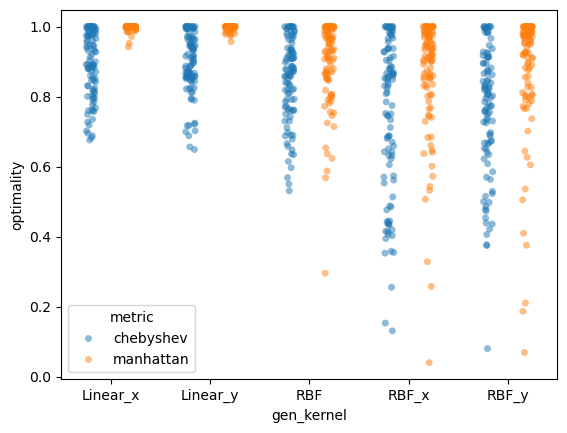

In [798]:
## plot optimality
data_tmp = df_gp.loc[
    # (df_gp['gen_kernel']=='RBF_x')
                     (df_gp['metric']=='chebyshev')|
                     (df_gp['metric']=='manhattan')
                     ]
# data_tmp = df_gp.copy()
# sns.violinplot(data = data_tmp, x = 'gen_kernel', y = 'optimality', hue = 'metric', split = True)
sns.stripplot(data = data_tmp, x = 'gen_kernel', y = 'optimality', hue = 'metric', dodge = True, alpha = 0.5)